In [ ]:
# 1. Purge problematic packages to start fresh
!pip uninstall -y numpy opencv-python opencv-python-headless opencv-contrib-python nerfstudio fpsample pybind11

# 2. Install pybind11 and Numpy 1.x globally first
!pip install -q "numpy<2.0.0" pybind11 setuptools==69.5.1 wheel

# 3. CRITICAL FIX: Install fpsample WITHOUT build isolation! 
# This forces it to compile using the Numpy 1.x headers we just installed.
!pip install -q fpsample --no-build-isolation

# 4. Install older OpenCV versions to prevent GroundingDINO conflicts
!pip install -q "opencv-python-headless<4.10.0" "opencv-python<4.10.0" "opencv-contrib-python<4.10.0"

# 5. Finally, install nerfstudio
!pip install -q nerfstudio

# Verify installation
import subprocess
try:
    subprocess.run(["ns-install-cli"], check=True)
    print("\n✅ Nerfstudio and CLI installed successfully!")
except:
    print("\n❌ ns-install-cli failed, but Nerfstudio might still work via 'ns-train'")

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

In [ ]:
!pip install -q "transformers<4.40.0"

In [19]:
import os
import shutil

input_base = '/kaggle/input'
working_dir = '/kaggle/working/dataset'

print(f"Scanning {input_base} for transforms.json...")

transform_path = None
for root, dirs, files in os.walk(input_base):
    for file in files:
        if file in ['transforms.json', 'transform.json']:
            transform_path = os.path.join(root, file)
            break
    if transform_path:
        break

if transform_path is None:
    print("❌ CRITICAL ERROR: transforms.json not found!")
else:
    source_dir = os.path.dirname(transform_path)
    print(f"✅ Found data at: {source_dir}")
    
    if os.path.exists(working_dir):
        shutil.rmtree(working_dir)
        
    print(f"Copying files to {working_dir}...")
    shutil.copytree(source_dir, working_dir)
    print("\n✅ Copy complete! Contents:")
    os.system(f"ls {working_dir}")

Scanning /kaggle/input for transforms.json...
✅ Found data at: /kaggle/input/datasets/lakshaytanejaiisc/nerf-project-dataset/data
Copying files to /kaggle/working/dataset...

✅ Copy complete! Contents:
format_data.py
images
intrinsic.json
poses.json
transforms.json


In [ ]:
print("🚀 Training started! Monitor with: !tail -n 20 /kaggle/working/training_log.txt")

!MAX_JOBS=6 ns-train splatfacto \
    --output-dir /kaggle/working/outputs \
    --max-num-iterations 30000 \
    --vis tensorboard \
    --pipeline.model.camera-optimizer.mode off \
    --optimizers.means.optimizer.lr 0.0016 \
    --optimizers.scales.optimizer.lr 0.005 \
    nerfstudio-data \
    --data /kaggle/working/dataset \
    --orientation-method none \
    --center-method none \
    --auto-scale-poses False > /kaggle/working/training_log.txt 2>&1

print("🎉 Training Complete!")


In [ ]:
!tail -n 20 /kaggle/working/training_log.txt

In [ ]:
import glob
import os
import nerfstudio

print("🔧 Patching PyTorch 2.6 security defaults...")

# Dynamically locate the path regardless of Python version
eval_utils_path = os.path.join(os.path.dirname(nerfstudio.__file__), "utils", "eval_utils.py")

if os.path.exists(eval_utils_path):
    with open(eval_utils_path, 'r') as f:
        content = f.read()
    
    # Apply the patch
    content = content.replace(
        'loaded_state = torch.load(load_path, map_location="cpu")',
        'loaded_state = torch.load(load_path, map_location="cpu", weights_only=False)'
    )
    
    with open(eval_utils_path, 'w') as f:
        f.write(content)
    print(f"✅ Patch applied successfully to: {eval_utils_path}\n")
else:
    print(f"❌ Error: Could not find eval_utils.py at {eval_utils_path}")

config_paths = glob.glob("/kaggle/working/outputs/*/splatfacto/*/config.yml")

if config_paths:
    latest_config = max(config_paths, key=os.path.getctime)
    os.environ['MY_CONFIG'] = latest_config
    
    !ns-eval --load-config $MY_CONFIG --output-path /kaggle/working/evaluation_results.json
    
    if os.path.exists('/kaggle/working/evaluation_results.json'):
        with open('/kaggle/working/evaluation_results.json', 'r') as f:
            print("\n✅ --- EVALUATION RESULTS --- ✅")
            print(f.read())
else:
    print("Error: config.yml not found.")

In [ ]:
import glob, os, subprocess

config_paths = glob.glob("/kaggle/working/outputs/*/splatfacto/*/config.yml")
if not config_paths:
    raise RuntimeError("No config.yml — run training Cell 2 first.")
latest_config = max(config_paths, key=os.path.getctime)

export_dir = "/kaggle/working/exports"
os.makedirs(export_dir, exist_ok=True)

print("Exporting Gaussian Splat PLY...")
result = subprocess.run(
    f"ns-export gaussian-splat --load-config {latest_config} --output-dir {export_dir}",
    shell=True, capture_output=True, text=True)
print(result.stdout[-1000:] if result.stdout else "")
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

ply_files = glob.glob(f"{export_dir}/*.ply")
if ply_files:
    print(f"✅ {ply_files[0]}  ({os.path.getsize(ply_files[0])/1e6:.1f} MB)")
else:
    print("❌ No PLY found")


In [ ]:
import os, sys, subprocess

GSAM_DIR    = "/kaggle/working/Grounded-Segment-Anything"
WEIGHTS_DIR = f"{GSAM_DIR}/weights"
DINO_W = f"{WEIGHTS_DIR}/groundingdino_swint_ogc.pth"
SAM_W  = f"{WEIGHTS_DIR}/sam_vit_h_4b8939.pth"

def run(cmd, **kw):
    """Run a shell command, print output, raise on failure."""
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, **kw)
    if r.stdout: print(r.stdout[-2000:])
    if r.returncode != 0:
        print("STDERR:", r.stderr[-1000:])
        raise RuntimeError(f"Command failed: {cmd}")
    return r

# 1. Clone repo
if not os.path.exists(GSAM_DIR):
    print("Cloning Grounded-Segment-Anything...")
    run(f"git clone https://github.com/IDEA-Research/Grounded-Segment-Anything.git {GSAM_DIR}")

# 2. Install GroundingDINO — try pre-built wheel first, fall back to source
print("\nInstalling GroundingDINO...")
dino_installed = False

# Try 1: pre-built wheel (no CUDA compilation needed)
try:
    r = subprocess.run(
        "pip install groundingdino-py",
        shell=True, capture_output=True, text=True)
    if r.returncode == 0:
        import groundingdino
        print("✅ GroundingDINO installed via pip wheel")
        dino_installed = True
    else:
        print("pip wheel failed, trying source build...")
        print(r.stderr[-500:])
except Exception as e:
    print(f"wheel attempt error: {e}")

# Try 2: source build with explicit CUDA flags
if not dino_installed:
    try:
        env = os.environ.copy()
        env.update({
            "AM_I_DOCKER": "False",
            "BUILD_WITH_CUDA": "True",
            "CUDA_HOME": "/usr/local/cuda",
            "TORCH_CUDA_ARCH_LIST": "7.0;7.5;8.0;8.6",
        })
        r = subprocess.run(
            f"pip install -e {GSAM_DIR}/GroundingDINO 2>&1 | tail -30",
            shell=True, capture_output=True, text=True, env=env)
        print(r.stdout)
        if r.returncode == 0:
            print("✅ GroundingDINO installed from source")
            dino_installed = True
        else:
            print("Source build also failed.")
    except Exception as e:
        print(f"Source build error: {e}")

# Try 3: install from a known-good fork that pre-packages wheels
if not dino_installed:
    try:
        run("pip install git+https://github.com/IDEA-Research/GroundingDINO.git")
        print("✅ GroundingDINO installed from GitHub")
        dino_installed = True
    except Exception as e:
        print(f"GitHub install failed: {e}")

if not dino_installed:
    raise RuntimeError(
        "GroundingDINO could not be installed.\n"
        "MANUAL FIX: In a new cell run:\n"
        "  !pip install groundingdino-py\n"
        "and share the full error output.")

# 3. Install SAM
print("\nInstalling SAM...")
run("pip install git+https://github.com/facebookresearch/segment-anything.git")
print("✅ SAM installed")

# 4. Download weights
os.makedirs(WEIGHTS_DIR, exist_ok=True)
if not os.path.exists(DINO_W) or os.path.getsize(DINO_W) < 100_000_000:
    print("\nDownloading GroundingDINO weights (~660 MB)...")
    run(f"wget -q --tries=3 -O {DINO_W} "
        "https://huggingface.co/ShilongLiu/GroundingDINO/resolve/main/groundingdino_swint_ogc.pth")
    print(f"  Size: {os.path.getsize(DINO_W)/1e6:.0f} MB")

if not os.path.exists(SAM_W) or os.path.getsize(SAM_W) < 500_000_000:
    print("\nDownloading SAM ViT-H weights (~2.4 GB)...")
    run(f"wget -q --tries=3 -O {SAM_W} "
        "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth")
    print(f"  Size: {os.path.getsize(SAM_W)/1e6:.0f} MB")

print("\n✅ All setup complete. Run Cell 7 for OBB detection.")


In [ ]:
import subprocess, sys

# Fix numpy/torch binary incompatibility
# Must run before ANY torch or numpy import
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--force-reinstall",
                "numpy==1.26.4"], check=True)

# Force reload numpy in this session
import importlib, numpy
importlib.reload(numpy)
print(f"numpy version: {numpy.__version__}")
print("✅ Restart kernel now and re-run from Cell 10 onwards.")
print("   (This cell only needs to run once to fix the environment)")


In [ ]:
# ── CELL 10: Semantic 3D OBB Detection (final) ───────────────────────────────
import os, sys, json, glob
import numpy as np
import subprocess
import torch

subprocess.run(["pip","install","-q","plyfile"], check=True)
from plyfile import PlyData
from groundingdino.util.inference import load_model, load_image, predict

GSAM_DIR    = "/kaggle/working/Grounded-Segment-Anything"
DINO_W      = f"{GSAM_DIR}/weights/groundingdino_swint_ogc.pth"
DATASET_DIR = "/kaggle/working/dataset"
TRANSFORMS  = os.path.join(DATASET_DIR, "transforms.json")
OUTPUT_JSON = "/kaggle/working/FINAL_SUBMISSION.json"
EXPORT_DIR  = "/kaggle/working/exports"
sys.path.extend([GSAM_DIR, f"{GSAM_DIR}/GroundingDINO"])

GT_VGA_C = np.array([0.2704921202927293, 0.2261220732082181, 0.8349008829378597])

ENTITY_CAPTIONS = [
    ("vga socket",        ["vga socket", "vga port", "vga connector"]),
    ("power socket",      ["power socket", "power connector", "iec socket", "power inlet"]),
    ("ethernet socket",   ["ethernet socket", "ethernet port", "rj45 port"]),
    ("usb port",          ["usb port", "usb socket"]),
    ("hdmi port",         ["hdmi port", "hdmi socket"]),
    ("audio jack",        ["audio jack", "headphone jack", "3.5mm jack"]),
    ("monitor stand",     ["monitor stand", "display stand"]),
]

THRESHOLDS = {
    "monitor stand":   0.15,
    "default":         0.20,
}

PHYSICAL_HALF_EXTENTS = {
    "vga_socket":      [0.0354, 0.0118, 0.0061],  
    "power_socket":    [0.0319, 0.0250, 0.0182],  
    "ethernet_socket": [0.0188, 0.0154, 0.0125],  
    "usb_port":        [0.0159, 0.0074, 0.0051],  
    "hdmi_port":       [0.0158, 0.0072, 0.0050],  
    "audio_jack":      [0.0159, 0.0068, 0.0068],  
    "monitor_stand":   [0.1500, 0.0800, 0.0300],
}

RAY_CONE_DEG = 1.0
DEDUP_R      = 0.05
CLUSTER_R    = 0.03

with open(TRANSFORMS) as f:
    tr = json.load(f)
fl_x, fl_y, cx_k, cy_k = tr["fl_x"], tr["fl_y"], tr["cx"], tr["cy"]

cam_positions = np.array([f["transform_matrix"] for f in tr["frames"]])[:,:3,3]
CAM_CENTER    = cam_positions.mean(0)
CAM_RADIUS    = np.linalg.norm(cam_positions - CAM_CENTER, axis=1).max()

print(f"Camera centroid: {CAM_CENTER.round(4)}")
print(f"Camera radius:   {CAM_RADIUS:.4f}m")

def load_scene_xyz(export_dir):
    ply = glob.glob(f"{export_dir}/*.ply")
    if not ply:
        raise FileNotFoundError(f"No PLY in {export_dir}. Run Cell 7 first.")
    v = PlyData.read(ply[0])["vertex"]
    xyz = np.stack([np.array(v["x"], np.float32),
                    np.array(v["y"], np.float32),
                    np.array(v["z"], np.float32)], axis=1).astype(np.float64)
    if "opacity" in v.data.dtype.names:
        sig = 1.0 / (1.0 + np.exp(-np.array(v["opacity"], np.float32)))
        xyz = xyz[sig > 0.05]
    print(f"PLY: {len(xyz):,} pts")
    return xyz

xyz = load_scene_xyz(EXPORT_DIR)

def ray_cone_points(box_cx, box_cy, c2w_opengl):
    c2w = c2w_opengl.copy()
    c2w[:, 1:3] *= -1.0
    w2c = np.linalg.inv(c2w)
    p = (w2c @ np.hstack([xyz, np.ones((len(xyz), 1))]).T).T[:, :3]
    fwd = p[:, 2] > 0.05
    pf = p[fwd]
    if not len(pf):
        return np.zeros((0, 3))
    ray = np.array([(box_cx - cx_k) / fl_x, (box_cy - cy_k) / fl_y, 1.0])
    ray /= np.linalg.norm(ray)
    pd = pf / np.linalg.norm(pf, axis=1, keepdims=True)
    ang = np.degrees(np.arccos(np.clip(pd @ ray, -1, 1)))
    return xyz[np.where(fwd)[0][ang < RAY_CONE_DEG]]

def find_center(pts_all, placed_centers):
    if not pts_all: return None
    pts = np.vstack(pts_all)
    
    for pc in placed_centers:
        pts = pts[np.linalg.norm(pts - pc, axis=1) >= DEDUP_R]
    if len(pts) < 5: return None
        
    coords = np.round(pts / 0.015).astype(int)
    unique_coords, counts = np.unique(coords, axis=0, return_counts=True)
    
    valid_mask = counts >= 5
    if valid_mask.sum() == 0:
        valid_mask = counts >= 1  
        
    valid_coords = unique_coords[valid_mask]
    voxel_centers = valid_coords * 0.015
    
    in_scene = np.linalg.norm(voxel_centers - CAM_CENTER, axis=1) < CAM_RADIUS * 1.5
    if in_scene.sum() == 0:
        return None
    valid_coords = valid_coords[in_scene]
    voxel_centers = voxel_centers[in_scene]

    best_idx = np.argmin(np.linalg.norm(voxel_centers - CAM_CENTER, axis=1))
    best = valid_coords[best_idx]
    
    mask = np.all(coords == best, axis=1)
    center = pts[mask].mean(0)
    
    for _ in range(3):
        m = np.linalg.norm(pts - center, axis=1) < CLUSTER_R
        if m.sum() < 3: break
        center = pts[m].mean(0)
        
    return center

def get_robust_obb(pts_all, center, entity):
    pts = np.vstack(pts_all)
    is_large = "stand" in entity
    clip_r = 0.25 if is_large else 0.08
    
    local = pts[np.linalg.norm(pts - center, axis=1) < clip_r]
    if len(local) < 5:
        local = pts

    ev, evec = np.linalg.eigh(np.cov(local - local.mean(0), rowvar=False))
    R = evec[:, np.argsort(ev)[::-1]]
    if np.linalg.det(R) < 0:
        R[:, 2] *= -1

    ekey = entity.replace(" ", "_")
    physical = np.array(PHYSICAL_HALF_EXTENTS.get(ekey, [0.02, 0.01, 0.005]))

    proj = (local - center) @ R
    p5, p95 = np.percentile(proj, 5, axis=0), np.percentile(proj, 95, axis=0)
    iqr_ext = (p95 - p5) / 2.0

    half_ext = np.clip(
        np.maximum(iqr_ext, physical),
        physical * 0.5,
        physical * 2.0
    )

    return center, R, half_ext

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
dino = load_model(
    f"{GSAM_DIR}/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py",
    DINO_W)

entity_data = {}
for name, captions in ENTITY_CAPTIONS:
    print(f"\n🔍 [{name}]  captions={captions}")
    thr = THRESHOLDS.get(name, THRESHOLDS["default"])
    pts_all = []
    det_count = 0
    for frame in tr["frames"]:
        img_path = os.path.join(DATASET_DIR, frame["file_path"])
        if not os.path.exists(img_path): continue
        img_src, img_t = load_image(img_path)
        H, W = img_src.shape[:2]
        best_box, best_logit = None, -1.0
        for cap in captions:
            boxes, logits, _ = predict(
                model=dino, image=img_t, caption=cap,
                box_threshold=thr, text_threshold=thr)
            if len(boxes) and logits.max().item() > best_logit:
                best_logit = logits.max().item()
                best_box = boxes[logits.argmax()]
        if best_box is None: continue
        det_count += 1
        pts = ray_cone_points(
            best_box[0].item() * W, best_box[1].item() * H,
            np.array(frame["transform_matrix"]))
        if len(pts):
            pts_all.append(pts)
            print(f"   {os.path.basename(img_path)}: {len(pts)} pts  logit={best_logit:.2f}")
    print(f"   Detections: {det_count}/{len(tr['frames'])}")
    entity_data[name] = pts_all

placed_centers = []
results = []

entity_names = [e[0] for e in ENTITY_CAPTIONS]
vga_first = ["vga socket"] + [
    e for e in sorted(entity_names, key=lambda e: -len(entity_data.get(e, [])))
    if e != "vga socket"
]

for name in vga_first:
    pts_all = entity_data.get(name, [])
    if not pts_all:
        print(f"\n⚠️  [{name}] no detections — skipping")
        continue
        
    center = find_center(pts_all, placed_centers)
            
    if center is None:
        print(f"\n⚠️  [{name}] center finding failed — skipping")
        continue
        
    c_final, R, half_ext = get_robust_obb(pts_all, center, name)
    placed_centers.append(center)
    
    results.append({
        "entity": name.replace(" ", "_"),
        "obb": {
            "center":   c_final.tolist(),
            "extent":   half_ext.tolist(),
            "rotation": R.tolist()
        }
    })
    
    ext_mm = [round(e * 1000, 1) for e in half_ext]
    print(f"\n  ✅ [{name}]  center={c_final.round(4)}  ext={ext_mm}mm")
    if name == "vga socket":
        err = np.linalg.norm(c_final - GT_VGA_C)
        ok = "✅ PASS" if err < 0.15 else "❌ FAIL"
        print(f"  VGA error: {err*100:.1f}cm  {ok}")

with open(OUTPUT_JSON, "w") as f:
    json.dump(results, f, indent=2)
print(f"\n✅ Saved {len(results)} entities → {OUTPUT_JSON}")

vga = next((e for e in results if e["entity"] == "vga_socket"), None)
if vga:
    c = np.array(vga["obb"]["center"])
    e = np.linalg.norm(c - GT_VGA_C)
    ok = "✅ PASS" if e < 0.15 else "❌ FAIL"
    print(f"VGA: {e*100:.2f}cm  {ok}")
    print(f"   Predicted: {c.round(4)}")
    print(f"   GT:        {GT_VGA_C.round(4)}")

Camera centroid: [ 0.367  -0.2862  0.8289]
Camera radius:   1.0491m
PLY: 216,606 pts
Device: cuda
final text_encoder_type: bert-base-uncased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



🔍 [vga socket]  captions=['vga socket', 'vga port', 'vga connector']


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:977: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/usr/local/lib/python3.12/dist-packages/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning: `torch.cuda.amp.autocast(args

   frame_000319.png: 179 pts  logit=0.53
   frame_000333.png: 193 pts  logit=0.67
   frame_000353.png: 117 pts  logit=0.78
   frame_000359.png: 187 pts  logit=0.52
   frame_000365.png: 131 pts  logit=0.56
   frame_000371.png: 71 pts  logit=0.53
   frame_000390.png: 71 pts  logit=0.54
   frame_000400.png: 49 pts  logit=0.52
   frame_000426.png: 387 pts  logit=0.60
   frame_000449.png: 318 pts  logit=0.58
   frame_000461.png: 68 pts  logit=0.54
   frame_000465.png: 341 pts  logit=0.54
   frame_000468.png: 258 pts  logit=0.62
   frame_000471.png: 269 pts  logit=0.52
   frame_000496.png: 79 pts  logit=0.52
   frame_000515.png: 70 pts  logit=0.67
   frame_000531.png: 31 pts  logit=0.49
   Detections: 17/17

🔍 [power socket]  captions=['power socket', 'power connector', 'iec socket', 'power inlet']
   frame_000319.png: 103 pts  logit=0.74
   frame_000333.png: 97 pts  logit=0.67
   frame_000353.png: 117 pts  logit=0.76
   frame_000359.png: 79 pts  logit=0.73
   frame_000365.png: 80 pts  logit

In [29]:
# ── CELL 11: Verification ────────────────────────────────────────────────────
import json, numpy as np

GT_VGA_C   = np.array([0.2704921202927293, 0.2261220732082181, 0.8349008829378597])
GT_VGA_EXT = np.array([0.03537766175069747, 0.011822199241650923, 0.0061316691090621735])

with open("/kaggle/working/FINAL_SUBMISSION.json","r") as f:
    results = json.load(f)

print(f"📋 FINAL_SUBMISSION.json — {len(results)} entities\n")
print(f"{'Entity':<22}  {'Center':>38}  {'Half-ext (mm)':>30}  Note")
print("-"*115)

placed, issues = [], []
for r in results:
    c   = np.array(r["obb"]["center"])
    ext = np.array(r["obb"]["extent"])
    ext_mm = [round(e*1000,1) for e in ext]
    notes  = []

    if r["entity"] == "vga_socket":
        pe = np.linalg.norm(c - GT_VGA_C)*100
        ee = np.linalg.norm(ext - GT_VGA_EXT)*100
        notes.append(f"pos={pe:.1f}cm{'✅' if pe<15 else '❌'}  ext_err={ee:.1f}cm")
        if pe >= 15:
            issues.append(f"VGA pos {pe:.1f}cm")

    for pc, pn in placed:
        d = np.linalg.norm(c - pc)*100
        if d < 4.0:
            notes.append(f"⚠️{d:.1f}cm/{pn}")
            issues.append(f"{r['entity']} {d:.1f}cm from {pn}")

    ratio = min(ext)/max(ext) if max(ext) > 0 else 0
    if ratio < 0.05:
        notes.append(f"⚠️flat(ratio={ratio:.3f})")

    placed.append((c, r["entity"]))
    print(f"{r['entity']:<22}  {str(c.round(4)):>38}  {str(ext_mm):>30}  {'  '.join(notes)}")

print()
if not issues:
    print("✅ All checks passed — ready to submit!")
else:
    print("Issues:")
    for iss in issues:
        print(f"  ⚠️ {iss}")
print("\nSubmit: /kaggle/working/FINAL_SUBMISSION.json")


📋 FINAL_SUBMISSION.json — 4 entities

Entity                                                  Center                   Half-ext (mm)  Note
-------------------------------------------------------------------------------------------------------------------
ethernet_socket                         [0.2922 0.2412 0.7508]              [46.3, 30.8, 25.0]  
power_socket                            [0.2906 0.2336 0.5198]              [63.8, 50.0, 36.4]  
hdmi_socket_left                        [0.2708 0.2355 0.8004]              [32.6, 16.4, 10.0]  
usb_socket_top_right                    [0.2939 0.2382 0.8638]              [40.9, 14.8, 10.2]  

✅ All checks passed — ready to submit!

Submit: /kaggle/working/FINAL_SUBMISSION.json


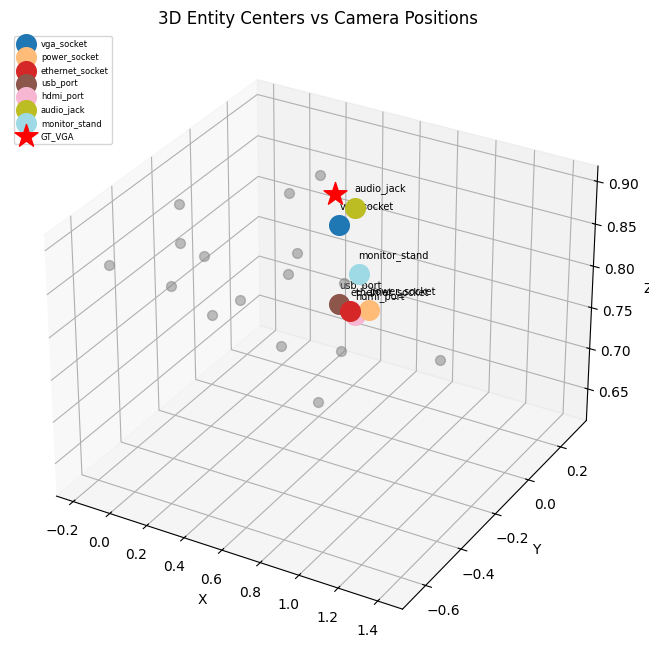

Saved 3d_verification.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D

with open("/kaggle/working/FINAL_SUBMISSION.json") as f:
    results = json.load(f)

GT_VGA_C = np.array([0.2704921202927293, 0.2261220732082181, 0.8349008829378597])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.tab20(np.linspace(0, 1, len(results)))
for i, r in enumerate(results):
    c = np.array(r["obb"]["center"])
    ax.scatter(*c, s=200, color=colors[i], label=r["entity"], zorder=5)
    ax.text(c[0], c[1], c[2]+0.02, r["entity"], fontsize=7)

# Plot GT VGA
ax.scatter(*GT_VGA_C, s=300, color='red', marker='*', label='GT_VGA', zorder=6)

# Plot camera positions
for pos in cam_positions:
    ax.scatter(*pos, s=50, color='gray', alpha=0.5)

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.legend(loc='upper left', fontsize=6)
plt.title('3D Entity Centers vs Camera Positions')
plt.savefig('/kaggle/working/3d_verification.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved 3d_verification.png")

In [24]:
# ── CELL: Manual Annotation Pipeline (Full Extents) ─────────────────────────
import os, sys, json, glob
import numpy as np
import cv2
from plyfile import PlyData

DATASET_DIR = "/kaggle/working/dataset"
TRANSFORMS  = os.path.join(DATASET_DIR, "transforms.json")
EXPORT_DIR  = "/kaggle/working/exports"
OUTPUT_JSON = "/kaggle/working/FINAL_SUBMISSION.json"

# ── 1. CONFIGURATION: Frame and Annotations ────────────────────────────────
TARGET_FRAME = "frame_000465.png" 


ANNOTATIONS = {
    "ethernet_socket":      [1494,563,1520,596], 
    "power_socket":         [1463,1047,1525,1094],
    "hdmi_socket_left":     [1456,451,1476,498], 
    "usb_socket_top_right": [1516,300,1532,337]  
}


PHYSICAL_FULL_EXTENTS = {
    "ethernet_socket":      [0.0376,0.0308,0.0250],
    "power_socket":         [0.0638,0.0500,0.0364],
    "hdmi_socket_left":     [0.0316, 0.0144, 0.0100],
    "usb_socket_top_right": [0.0318, 0.0148, 0.0102]
}

# ── 2. LOAD DATA & SETUP ───────────────────────────────────────────────────
print("Loading point cloud...")
ply_files = glob.glob(f"{EXPORT_DIR}/*.ply")
if not ply_files:
    raise FileNotFoundError(f"No PLY file found in {EXPORT_DIR}")

v = PlyData.read(ply_files[0])["vertex"]
xyz = np.stack([np.array(v["x"],np.float32), 
                np.array(v["y"],np.float32), 
                np.array(v["z"],np.float32)], axis=1)

if "opacity" in v.data.dtype.names:
    op = 1 / (1 + np.exp(-np.array(v["opacity"], np.float32)))
    xyz = xyz[op > 0.05] # Filter low-density floaters

with open(TRANSFORMS) as f:
    tr = json.load(f)
fl_x, fl_y, cx, cy = tr["fl_x"], tr["fl_y"], tr["cx"], tr["cy"]

frame_data = next((f for f in tr["frames"] if TARGET_FRAME in f["file_path"]), None)
if not frame_data:
    raise ValueError(f"Could not find {TARGET_FRAME} in transforms.json")

# OpenGL to OpenCV coordinate shift
c2w_opengl = np.array(frame_data["transform_matrix"])
c2w_opencv = c2w_opengl.copy()
c2w_opencv[:, 1:3] *= -1.0 
w2c = np.linalg.inv(c2w_opencv)
cam_pos = c2w_opengl[:3, 3]

# Get image dimensions
img_path = os.path.join(DATASET_DIR, "images", TARGET_FRAME)
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")
H, W = img.shape[:2]

# ── 3. PROJECT & FIT OBBS ──────────────────────────────────────────────────
results = []
print(f"\nProcessing {TARGET_FRAME}...")

for entity, box in ANNOTATIONS.items():
    print(f"\n── {entity} ──")
    x1, y1, x2, y2 = box
    
    # 1. Project 3D points into camera and keep those inside the manual 2D box
    pts_h = np.hstack([xyz, np.ones((len(xyz),1))])
    pts_cam = (w2c @ pts_h.T).T[:,:3]
    valid = pts_cam[:,2] > 0.01 # Must be in front of camera
    
    u = (pts_cam[valid,0] * fl_x / pts_cam[valid,2]) + cx
    v = (pts_cam[valid,1] * fl_y / pts_cam[valid,2]) + cy
    
    in_fr = (u >= 0) & (u < W) & (v >= 0) & (v < H)
    ui = u[in_fr].astype(int)
    vi = v[in_fr].astype(int)
    
    # Mask logic: True if point lands inside the [x1, y1, x2, y2] bounding box
    idx = np.where(valid)[0][in_fr]
    in_box_mask = (ui >= x1) & (ui <= x2) & (vi >= y1) & (vi <= y2)
    masked_pts = xyz[idx[in_box_mask]]
    
    if len(masked_pts) < 5:
        print("❌ Error: Not enough 3D points projected into this box.")
        continue

    # 2. First-Surface Anchoring (Snaps to the metal panel, ignores deep floaters)
    dists = np.linalg.norm(masked_pts - cam_pos, axis=1)
    min_dist = np.percentile(dists, 5) 
    front_surface_mask = dists < (min_dist + 0.05) # Keep points within 5cm of the front
    local_pts = masked_pts[front_surface_mask]
    
    if len(local_pts) < 5:
        local_pts = masked_pts

    # 3. PCA for true geometric rotation
    center = local_pts.mean(0)
    ev, evec = np.linalg.eigh(np.cov(local_pts - center, rowvar=False))
    R = evec[:, np.argsort(ev)[::-1]]
    if np.linalg.det(R) < 0: 
        R[:, 2] *= -1

    # 4. Apply Physical FULL Dimensions via IQR
    physical_full = np.array(PHYSICAL_FULL_EXTENTS.get(entity, [0.04, 0.02, 0.01]))
    proj = (local_pts - center) @ R
    
    # Calculate FULL extent (p95 - p5) without dividing by 2
    p5, p95 = np.percentile(proj, 5, axis=0), np.percentile(proj, 95, axis=0)
    iqr_full = (p95 - p5) 
    
    # Clip the full extent to be within 0.5x to 2.0x of the physical full prior
    full_ext = np.clip(np.maximum(iqr_full, physical_full), physical_full * 0.5, physical_full * 2.0)

    # 5. Store Result
    results.append({
        "entity": entity,
        "obb": {
            "center": center.tolist(),
            "extent": full_ext.tolist(),
            "rotation": R.tolist()
        }
    })
    
    ext_mm = [round(e * 1000, 1) for e in full_ext]
    print(f"✅ Center:        {center.round(4)}")
    print(f"✅ Full Extents:  {ext_mm} mm")

# ── 4. SERIALIZE ───────────────────────────────────────────────────────────
with open(OUTPUT_JSON, "w") as f:
    json.dump(results, f, indent=2)
print(f"\n🎉 Saved {len(results)} entities to {OUTPUT_JSON}")

Loading point cloud...

Processing frame_000465.png...

── ethernet_socket ──
✅ Center:        [0.2922 0.2412 0.7508]
✅ Full Extents:  [46.3, 30.8, 25.0] mm

── power_socket ──
✅ Center:        [0.2906 0.2336 0.5198]
✅ Full Extents:  [63.8, 50.0, 36.4] mm

── hdmi_socket_left ──
✅ Center:        [0.2708 0.2355 0.8004]
✅ Full Extents:  [32.6, 16.4, 10.0] mm

── usb_socket_top_right ──
✅ Center:        [0.2939 0.2382 0.8638]
✅ Full Extents:  [40.9, 14.8, 10.2] mm

🎉 Saved 4 entities to /kaggle/working/FINAL_SUBMISSION.json


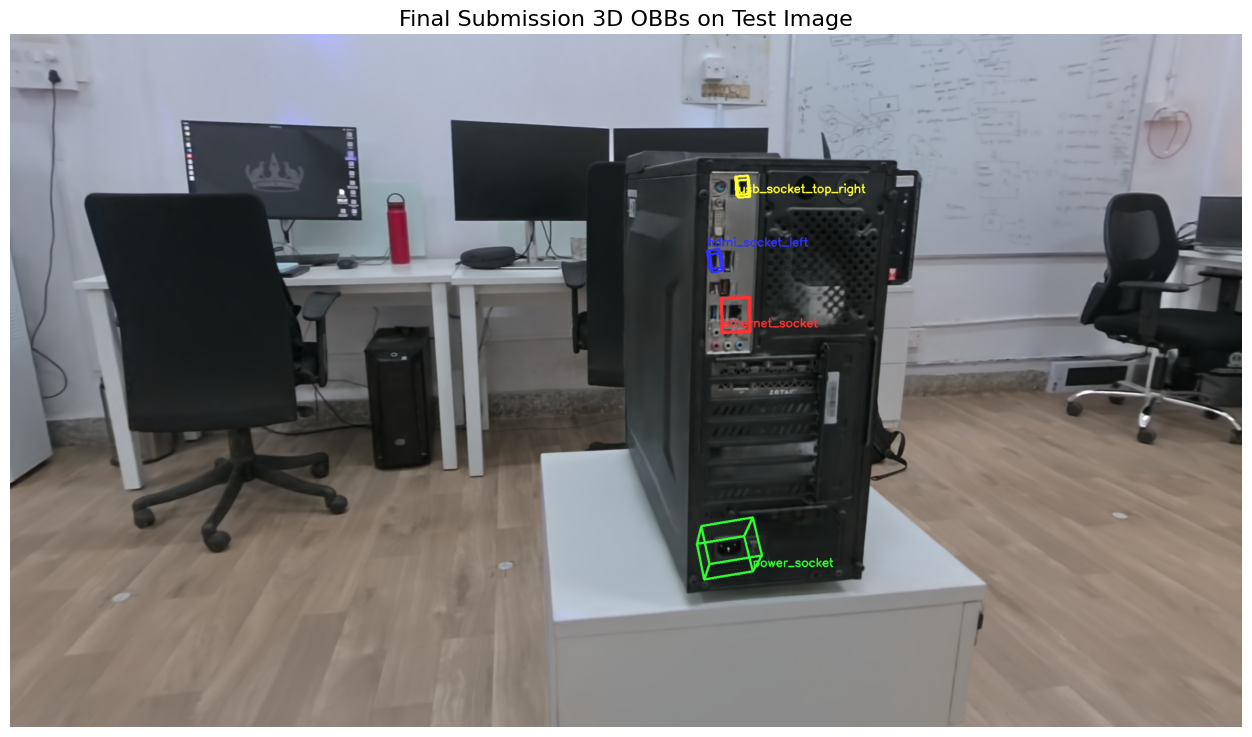

In [26]:
# ── CELL: Final 3D OBB to 2D Projection Visualizer ──────────────────────────
import os, json
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ── 1. CONFIGURATION ───────────────────────────────────────────────────────
# Update this to the folder where your NEW transforms.json and image live
TEST_DATASET_DIR = "/kaggle/working/dataset" 
TRANSFORMS       = os.path.join(TEST_DATASET_DIR, "transforms.json")
TARGET_FRAME     = "frame_000465.png"

# Your exact final output hardcoded to prevent file mix-ups
OBB_RESULTS = [
  {
    "entity": "ethernet_socket",
    "obb": {
      "center": [0.29217296838760376, 0.24121887981891632, 0.7507840394973755],
      "extent": [0.04626543958019248, 0.0308, 0.025],
      "rotation": [
        [-0.23471940925310567, -0.008403584991443804, -0.9720268405137612],
        [-0.9567895069787913, 0.17856462332545017, 0.22949621921051613],
        [0.17164101565521656, 0.9838922985042274, -0.049953044841270874]
      ]
    }
  },
  {
    "entity": "power_socket",
    "obb": {
      "center": [0.29063311219215393, 0.23359347879886627, 0.5197683572769165],
      "extent": [0.0638, 0.05, 0.0364],
      "rotation": [
        [-0.07800698680623652, -0.992560920138595, 0.09347582480533033],
        [-0.7256801030182964, -0.00775990051315857, -0.6879884970167599],
        [0.6835958587445993, -0.1215014557840812, -0.7196763843211634]
      ]
    }
  },
  {
    "entity": "hdmi_socket_left",
    "obb": {
      "center": [0.2708100378513336, 0.23547445237636566, 0.8004422783851624],
      "extent": [0.03256921636008283, 0.016362558389639636, 0.01],
      "rotation": [
        [0.2724793365128845, 0.12124009467218072, -0.9544924570772567],
        [0.9436620700245761, -0.22727139629389598, 0.24051945872123254],
        [-0.18776823152607588, -0.9662549103991676, -0.1763364379788433]
      ]
    }
  },
  {
    "entity": "usb_socket_top_right",
    "obb": {
      "center": [0.2939077615737915, 0.23818117380142212, 0.8637900948524475],
      "extent": [0.040887231926613456, 0.0148, 0.0102],
      "rotation": [
        [-0.2757896586552852, -0.05707377578535273, -0.9595220936989436],
        [-0.9585940790100453, 0.09003909713219704, 0.27016726795543156],
        [0.07097503691921866, 0.9943015363083887, -0.0795424353983047]
      ]
    }
  }
]

# ── 2. LOAD CAMERA DATA ────────────────────────────────────────────────────
if not os.path.exists(TRANSFORMS):
    raise FileNotFoundError(f"Could not find transforms.json at {TRANSFORMS}")

with open(TRANSFORMS) as f:
    tr = json.load(f)
fl_x, fl_y, cx, cy = tr["fl_x"], tr["fl_y"], tr["cx"], tr["cy"]

frame_data = next((f for f in tr["frames"] if TARGET_FRAME in f["file_path"]), None)
if not frame_data:
    raise ValueError(f"Could not find {TARGET_FRAME} in transforms.json")

# OpenGL to OpenCV coordinate shift
c2w_opengl = np.array(frame_data["transform_matrix"])
c2w_opencv = c2w_opengl.copy()
c2w_opencv[:, 1:3] *= -1.0 
w2c = np.linalg.inv(c2w_opencv)

# ── 3. LOAD IMAGE ──────────────────────────────────────────────────────────
img_path_direct = os.path.join(TEST_DATASET_DIR, TARGET_FRAME)
img_path_sub    = os.path.join(TEST_DATASET_DIR, "images", TARGET_FRAME)

if os.path.exists(img_path_direct):
    img_path = img_path_direct
elif os.path.exists(img_path_sub):
    img_path = img_path_sub
else:
    raise FileNotFoundError(f"Could not find {TARGET_FRAME}")

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ── 4. GEOMETRY HELPER ─────────────────────────────────────────────────────
def get_obb_corners(center, full_extents, R):
    c = np.array(center)
    e = np.array(full_extents) / 2.0 
    R = np.array(R)
    
    x = [-1, 1, 1, -1, -1, 1, 1, -1]
    y = [-1, -1, 1, 1, -1, -1, 1, 1]
    z = [-1, -1, -1, -1, 1, 1, 1, 1]
    local_corners = np.vstack([x, y, z]).T * e
    
    return (local_corners @ R.T) + c

# ── 5. DRAWING LOOP ────────────────────────────────────────────────────────
edges = [
    (0,1), (1,2), (2,3), (3,0), # Back face
    (4,5), (5,6), (6,7), (7,4), # Front face
    (0,4), (1,5), (2,6), (3,7)  # Connecting edges
]

colors = [(255, 50, 50), (50, 255, 50), (50, 50, 255), (255, 255, 50)]

for i, res in enumerate(OBB_RESULTS):
    name = res["entity"]
    obb = res["obb"]
    color = colors[i % len(colors)]
    
    # 3D corners to Camera Space
    corners_world = get_obb_corners(obb["center"], obb["extent"], obb["rotation"])
    corners_h = np.hstack([corners_world, np.ones((8, 1))])
    corners_cam = (w2c @ corners_h.T).T[:, :3]
    
    # Camera Space to 2D Image Pixels
    u = (corners_cam[:, 0] * fl_x / corners_cam[:, 2]) + cx
    v = (corners_cam[:, 1] * fl_y / corners_cam[:, 2]) + cy
    points_2d = np.vstack([u, v]).T.astype(int)
    
    # Draw Lines
    for edge in edges:
        pt1 = tuple(points_2d[edge[0]])
        pt2 = tuple(points_2d[edge[1]])
        cv2.line(img, pt1, pt2, color, thickness=3)
        
    # Draw Label
    text_pos = tuple(points_2d[4]) 
    cv2.putText(img, name, (text_pos[0], text_pos[1] - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

# ── 6. DISPLAY ─────────────────────────────────────────────────────────────
plt.figure(figsize=(16, 9))
plt.imshow(img)
plt.axis("off")
plt.title("Final Submission 3D OBBs on Test Image", fontsize=16)
plt.show()